# Mutual Fund Analytics Capstone

# Performance Analytics

This notebook computes advanced mutual fund performance metrics including:

- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import plotly.express as px

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
print(nav.head())

print(nav.shape)

print(nav.dtypes)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
(46000, 3)
amfi_code      int64
date          object
nav          float64
dtype: object


# Step 2: Daily Returns

In [4]:
# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Sort
nav = nav.sort_values(["amfi_code", "date"])

# Daily Return
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav.head())

print(nav["daily_return"].describe())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


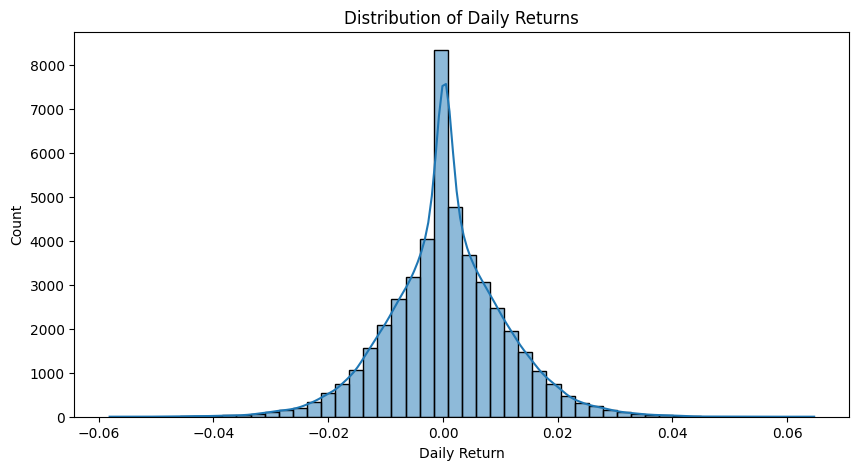

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.show()

# Step 3: CAGR Calculation

In [6]:
def calculate_cagr(df, years):

    results = []

    for code, group in df.groupby("amfi_code"):

        group = group.sort_values("date")

        if len(group) < 2:
            continue

        end_nav = group.iloc[-1]["nav"]

        start_date = group.iloc[-1]["date"] - pd.DateOffset(years=years)

        start = group[group["date"] >= start_date]

        if len(start) == 0:
            continue

        start_nav = start.iloc[0]["nav"]

        cagr = ((end_nav/start_nav)**(1/years)-1)*100

        results.append([code,cagr])

    return pd.DataFrame(results,columns=["amfi_code",f"CAGR_{years}Y"])

In [7]:
cagr1 = calculate_cagr(nav,1)
cagr3 = calculate_cagr(nav,3)
cagr5 = calculate_cagr(nav,5)

cagr = cagr1.merge(cagr3,on="amfi_code",how="outer")
cagr = cagr.merge(cagr5,on="amfi_code",how="outer")

display(cagr.head())

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.224271,1.292649,2.316843
1,100025,3.704969,3.916390,3.912653
2,100033,53.232396,32.442459,26.074068
3,101206,47.924120,28.967695,20.442730
4,101207,-23.986032,-4.152381,6.953336


# Step 4 – Sharpe Ratio

In [8]:
risk_free = 0.065

sharpe=[]

for code,group in nav.groupby("amfi_code"):

    r=group["daily_return"].dropna()

    if len(r)==0:
        continue

    annual_return=r.mean()*252

    annual_std=r.std()*np.sqrt(252)

    ratio=(annual_return-risk_free)/annual_std

    sharpe.append([code,ratio])

sharpe=pd.DataFrame(sharpe,columns=["amfi_code","Sharpe"])

display(sharpe.head())

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


# Step 5 – Sortino Ratio

In [9]:
sortino=[]

for code,group in nav.groupby("amfi_code"):

    r=group["daily_return"].dropna()

    downside=r[r<0]

    if len(downside)==0:
        continue

    downside_std=downside.std()*np.sqrt(252)

    annual_return=r.mean()*252

    ratio=(annual_return-risk_free)/downside_std

    sortino.append([code,ratio])

sortino=pd.DataFrame(sortino,columns=["amfi_code","Sortino"])

display(sortino.head())

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


# Step 6 – Alpha & Beta

In [10]:
benchmark["date"]=pd.to_datetime(benchmark["date"])

benchmark=benchmark.sort_values("date")

benchmark["benchmark_return"]=benchmark["close_value"].pct_change()

alpha_beta=[]

for code,group in nav.groupby("amfi_code"):

    merged=group.merge(
        benchmark[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    merged=merged.dropna()

    if len(merged)<30:
        continue

    slope,intercept,r,p,std=linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha=intercept*252

    beta=slope

    alpha_beta.append([code,alpha,beta])

alpha_beta=pd.DataFrame(
    alpha_beta,
    columns=["amfi_code","Alpha","Beta"]
)

display(alpha_beta.head())

,amfi_code,Alpha,Beta
0,100016,0.037661,-0.000003
1,100025,0.044818,-0.000003
2,100033,0.265138,0.000012
3,101206,0.208464,0.000011
4,101207,0.109861,-0.000005


In [11]:
alpha_beta.to_csv("../data/processed/alpha_beta.csv",index=False)

# Step 7 – Maximum Drawdown

In [12]:
drawdown=[]

for code,group in nav.groupby("amfi_code"):

    running_max=group["nav"].cummax()

    dd=(group["nav"]/running_max)-1

    drawdown.append([code,dd.min()])

drawdown=pd.DataFrame(
    drawdown,
    columns=["amfi_code","Max_Drawdown"]
)

display(drawdown.head())

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


# Step 8 – Fund Scorecard

In [13]:
score=performance.merge(sharpe,on="amfi_code")

score=score.merge(alpha_beta,on="amfi_code")

score=score.merge(drawdown,on="amfi_code")

score["Score"]=(
0.30*score["return_3yr_pct"].rank(pct=True)
+
0.25*score["Sharpe"].rank(pct=True)
+
0.20*score["Alpha"].rank(pct=True)
+
0.15*(1-score["expense_ratio_pct"].rank(pct=True))
+
0.10*(1-score["Max_Drawdown"].rank(pct=True))
)*100

score=score.sort_values("Score",ascending=False)

display(score.head())

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Sharpe,Alpha,Beta,Max_Drawdown,Score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,-13.35,19259,1.43,5,Very High,0.945308,0.295143,0.000013,-0.287060,81.7500
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,-21.84,979,1.36,3,High,1.180101,0.278249,0.000025,-0.181885,80.6250
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,-17.01,35124,1.52,4,Very High,0.949796,0.296003,0.000008,-0.311719,77.8125
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,-13.67,23185,1.38,5,High,1.093699,0.265138,0.000012,-0.162172,75.3750
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,-19.50,35012,1.45,5,Moderately High,1.306744,0.260693,0.000020,-0.129740,73.6250


In [14]:
score.to_csv("../data/processed/fund_scorecard.csv",index=False)

# Step 9 – Benchmark Comparison

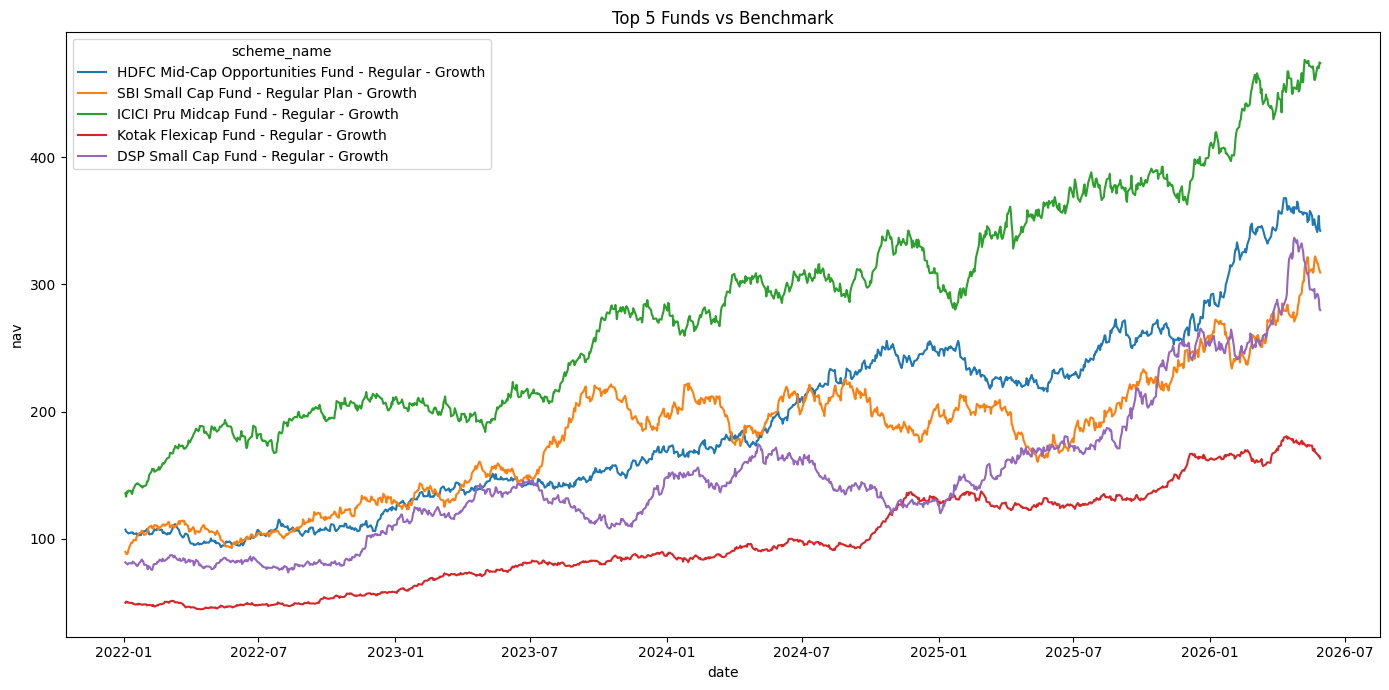

In [15]:
top5=score.head(5)["amfi_code"]

plot=nav[nav["amfi_code"].isin(top5)]

plot=plot.merge(
fund_master[["amfi_code","scheme_name"]],
on="amfi_code"
)

plt.figure(figsize=(14,7))

sns.lineplot(
data=plot,
x="date",
y="nav",
hue="scheme_name"
)

plt.title("Top 5 Funds vs Benchmark")

plt.tight_layout()

plt.savefig("../reports/charts/benchmark_comparison.png")

plt.show()